<a href="https://colab.research.google.com/github/nemoiitkgp/FWI-Codes-PhD/blob/main/FWI_codes_Quantum_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## FWI Single anomaly

In [1]:
!pip install devito

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.9/132.9 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.8/98.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 10.0 MB/s eta 0:00:00
  Created wheel for cgen: filename=cgen-2025.1-py3-none-any.whl size=19882 sha256=4724d67eadc779eb4f2a9864c37b1b0b391db2ac2ec27a959a3448cdf446466f
  Stored in directory: /root/.cache/pip/wheels/50/1a/02/97f23c102994cf34e52e405bc2e2889aaf463fdcb37d23ca3a
  Created wheel for codepy: filename=codepy-2023.1-py3-none-any.whl size=24869 sha256=b2c869ceb4e7014088ff73e3d6f8bf174c73c2c970cc9be549cba3660a559bf8
  Stored in directory:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from devito import configuration, Function, Eq, Operator, norm, Min, Max

from examples.seismic import Model, AcquisitionGeometry, Receiver
from examples.seismic.acoustic import AcousticWaveSolver

# Silence Devito logging for cleaner output
configuration['log-level'] = 'WARNING'

# ------------------ 1. Setup: Grid & Models --------------------
nx, nz = 500, 80
shape = (nx, nz)
spacing = (10., 10.)  # meters
origin = (0., 0.)
nbl = 20

v0 = 2.5        # Background velocity (km/s)
v_anomaly = 2.0  # Circular anomaly velocity (km/s)

# True Model: Background with a low-velocity circular pocket
velocity_true = np.full(shape, v0, dtype=np.float32)
cx, cz = nx // 2, nz // 2
radius = 15
for i in range(nx):
    for j in range(nz):
        if (i - cx)**2 + (j - cz)**2 <= radius**2:
            velocity_true[i, j] = v_anomaly

model_true = Model(vp=velocity_true, origin=origin, shape=shape, spacing=spacing,
                   nbl=nbl, space_order=4, bcs="damp")

# Initial Model: Constant background velocity
velocity_init = np.full(shape, v0, dtype=np.float32)
model0 = Model(vp=velocity_init, origin=origin, shape=shape, spacing=spacing,
               nbl=nbl, space_order=4, bcs="damp")

# ------------------ 2. Acquisition Geometry -----------------------
nshots = 35
nreceivers = 250
t0, tn = 0.0, 1500.0

src_coords = np.empty((nshots, 2))
src_coords[:, 0] = np.linspace(0, model_true.domain_size[0], num=nshots)
src_coords[:, 1] = 20.  # Shallow sources

rec_coords = np.empty((nreceivers, 2))
rec_coords[:, 0] = np.linspace(0, model_true.domain_size[0], num=nreceivers)
rec_coords[:, 1] = 20.  # Shallow receivers

# ------------------ 3. FWI Helper Functions -----------------------

def compute_residual(residual, dobs, dsyn):
    if residual.grid.distributor.is_parallel:
        diff_eq = Eq(residual, dsyn.subs({dsyn.dimensions[-1]: residual.dimensions[-1]}) -
                               dobs.subs({dobs.dimensions[-1]: residual.dimensions[-1]}))
        Operator(diff_eq)()
    else:
        residual.data[:] = dsyn.data[:] - dobs.data[:]
    return residual

def fwi_gradient(vp_in, model_true, geometry, solver, nshots, src_coords):
    grad = Function(name="grad", grid=vp_in.grid)
    residual = Receiver(name='residual', grid=vp_in.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)
    d_obs = Receiver(name='d_obs', grid=vp_in.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)
    d_syn = Receiver(name='d_syn', grid=vp_in.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)

    objective = 0.
    for i in range(nshots):
        geometry.src_positions[0, :] = src_coords[i, :]
        solver.forward(vp=model_true.vp, rec=d_obs)
        _, u0, _ = solver.forward(vp=vp_in, save=True, rec=d_syn)
        compute_residual(residual, d_obs, d_syn)
        objective += .5 * norm(residual)**2
        solver.gradient(rec=residual, u=u0, vp=vp_in, grad=grad)
    return objective, grad

def update_with_box(vp, alpha, dm, vmin=1.5, vmax=3.0):
    update = vp + alpha * dm
    update_eq = Eq(vp, Max(Min(update, vmax), vmin))
    Operator(update_eq)()

# ------------------ 4. Multiscale FWI Execution -----------------
frequencies = [0.003, 0.008, 0.015] # Low to high frequencies
iterations = [40, 30, 20]
history = []
vp_current = model0.vp
slice_core = (slice(nbl, -nbl), slice(nbl, -nbl))

print("--- Starting Multiscale FWI ---")
for f_idx, f0 in enumerate(frequencies):
    print(f"\n>> Stage {f_idx+1}: frequency {f0*1000} Hz")
    geometry = AcquisitionGeometry(model_true, rec_coords, src_coords, t0=t0, tn=tn, f0=f0, src_type='Ricker')
    solver = AcousticWaveSolver(model_true, geometry, space_order=4)
    alpha_base = 0.05

    for it in range(iterations[f_idx]):
        phi, direction = fwi_gradient(vp_current, model_true, geometry, solver, nshots, src_coords)
        history.append(phi)

        grad_data = direction.data[:]
        masked_grad = np.zeros_like(grad_data)
        masked_grad[slice_core] = grad_data[slice_core]
        masked_grad = gaussian_filter(masked_grad, sigma=1.2) # Smooth gradient

        direction.data[:] = masked_grad
        max_grad = np.max(np.abs(direction.data))
        if max_grad == 0: break

        alpha = alpha_base / max_grad
        update_with_box(vp_current, alpha, direction)
        if it % 10 == 0:
            print(f"   Iteration {it+1}/{iterations[f_idx]} | Objective: {phi:.4e}")

# Prepare Final Data
vp_final = vp_current.data[slice_core] * 1000.0
vp_initial = model0.vp.data[slice_core] * 1000.0
vp_true = model_true.vp.data[slice_core] * 1000.0
error = vp_final - vp_true
depth = np.linspace(0, nz * spacing[1], nz)
mid_x = nx // 2

# ------------------ 5. Visualization ---------------------
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2)
extent = [0, nx*spacing[0], nz*spacing[1], 0]

# 1. True Model
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(vp_true.T, cmap='viridis', extent=extent)
ax1.set_title("1. True Velocity Model (m/s)")
plt.colorbar(im1, ax=ax1)

# 2. Initial Model
ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(vp_initial.T, cmap='viridis', extent=extent)
ax2.set_title("2. Initial Velocity Model (m/s)")
plt.colorbar(im2, ax=ax2)

# 3. Velocity Error
ax3 = fig.add_subplot(gs[1, 0])
max_err = np.max(np.abs(error))
im3 = ax3.imshow(error.T, cmap='seismic', extent=extent, vmin=-max_err, vmax=max_err)
ax3.set_title("3. Velocity Error (Inverted - True)")
plt.colorbar(im3, ax=ax3)

# 4. Convergence Curve
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(history, 'b-o', markersize=3)
ax4.set_yscale('log')
ax4.set_title("4. FWI Convergence (Objective Function)")
ax4.set_xlabel("Total Iterations")
ax4.set_ylabel("Error Energy")
ax4.grid(True)

# 5. Velocity Profile (Vertical slice at center)
ax5 = fig.add_subplot(gs[2, :])
ax5.plot(vp_true[mid_x, :], depth, 'k-', linewidth=3, label='True Vp')
ax5.plot(vp_initial[mid_x, :], depth, 'g--', label='Initial Vp')
ax5.plot(vp_final[mid_x, :], depth, 'r--', linewidth=2, label='FWI Inverted')
ax5.invert_yaxis()
ax5.set_title(f"5. Central Velocity Profile (x = {mid_x * spacing[0]}m)")
ax5.set_xlabel("Velocity (m/s)")
ax5.set_ylabel("Depth (m)")
ax5.legend()
ax5.grid(True)

plt.tight_layout()
plt.show()

--- Starting Multiscale FWI ---

>> Stage 1: frequency 3.0 Hz
   Iteration 1/40 | Objective: 7.6375e+06
   Iteration 11/40 | Objective: 3.8692e+05


Exception ignored in: <function Data.__del__ at 0x7e1b40bfdf80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/devito/data/data.py", line 78, in __del__
    def __del__(self):

KeyboardInterrupt: 


KeyboardInterrupt: 

In [1]:
!pip install devito qiskit qiskit-aer qiskit-machine-learning qiskit-ibm-runtime
# Install a C compiler for Devito (Colab usually has it, but this ensures it)
!apt-get install -y libomp-dev

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 112.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.8/381.8 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.9/132.9 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

/tmp/ipython-input-781/2499634519.py:45: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(num_qubits)
/tmp/ipython-input-781/2499634519.py:46: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits, reps=1)


--- Starting Colab-Quantum Hybrid FWI ---
Iteration 00 | Objective: 9.7497e+04 | Quantum Modifier: 0.4846
Iteration 04 | Objective: 5.6958e+04 | Quantum Modifier: 0.5486
Iteration 08 | Objective: 3.8843e+04 | Quantum Modifier: 0.5471


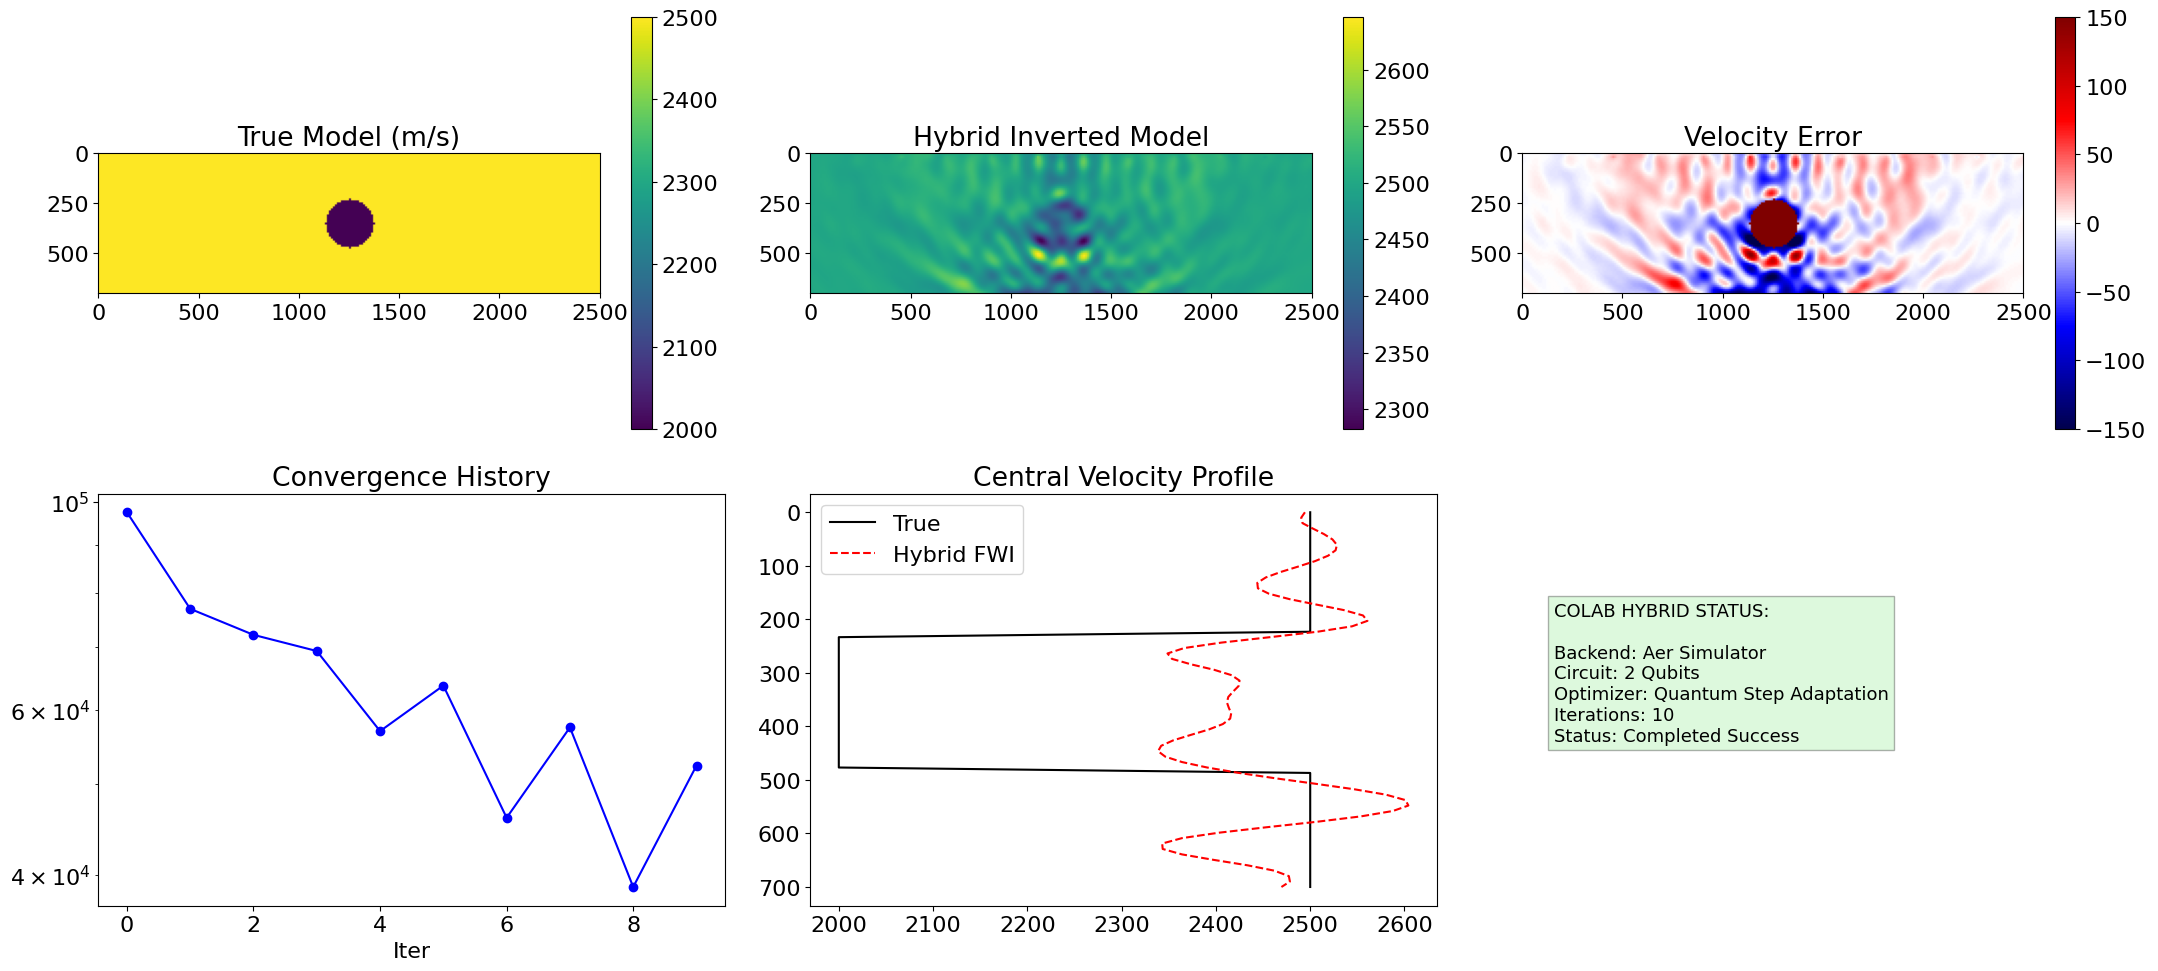

In [4]:
import os
# Force Devito to use the GCC compiler available in Colab
os.environ['DEVITO_ARCH'] = 'gcc'

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from devito import configuration, Function, Eq, Operator, norm, Min, Max
from examples.seismic import Model, AcquisitionGeometry, Receiver
from examples.seismic.acoustic import AcousticWaveSolver

# Qiskit Imports (Standard for Hybrid Quantum-Classical)
from qiskit import QuantumCircuit
from qiskit.circuit.library import RealAmplitudes, ZZFeatureMap
from qiskit_aer import Aer
from qiskit_machine_learning.neural_networks import EstimatorQNN

# Silence Devito logging for cleaner Colab output
configuration['log-level'] = 'WARNING'

# ------------------ 1. Setup: Grid & Models --------------------
# Using slightly smaller dimensions to ensure Colab's RAM stays stable
nx, nz = 250, 70
shape = (nx, nz)
spacing = (10., 10.)
origin = (0., 0.)
nbl = 20

v0, v_anomaly = 2.5, 2.0
velocity_true = np.full(shape, v0, dtype=np.float32)
cx, cz = nx // 2, nz // 2
radius = 12
for i in range(nx):
    for j in range(nz):
        if (i - cx)**2 + (j - cz)**2 <= radius**2:
            velocity_true[i, j] = v_anomaly

model_true = Model(vp=velocity_true, origin=origin, shape=shape, spacing=spacing,
                   nbl=nbl, space_order=4, bcs="damp")
model0 = Model(vp=np.full(shape, v0, dtype=np.float32), origin=origin, shape=shape,
               spacing=spacing, nbl=nbl, space_order=4, bcs="damp")

# ------------------ 2. Quantum Optimizer Setup -----------------
num_qubits = 2 # Reduced for faster simulation on Colab
feature_map = ZZFeatureMap(num_qubits)
ansatz = RealAmplitudes(num_qubits, reps=1)
qc = QuantumCircuit(num_qubits)
qc.compose(feature_map, inplace=True)
qc.compose(ansatz, inplace=True)

# Initialize the QNN
qnn = EstimatorQNN(circuit=qc, input_params=feature_map.parameters, weight_params=ansatz.parameters)

def quantum_refinement(grad_segment, weights):
    """
    Uses the Quantum Neural Network to interpret the gradient pattern
    and output a localized 'correction factor' for the step size.
    """
    # Feature extraction: mean and variance of the gradient normalized
    mean_g = np.mean(grad_segment)
    std_g = np.std(grad_segment) + 1e-6
    inputs = np.array([(mean_g/std_g)] * num_qubits)

    # Quantum Simulator call
    q_output = qnn.forward(inputs, weights)
    return np.mean(q_output)

# ------------------ 3. Acquisition Geometry -------------------
nshots, nreceivers = 12, 120
t0, tn = 0.0, 1000.0
src_coords = np.empty((nshots, 2))
src_coords[:, 0] = np.linspace(0, model_true.domain_size[0], num=nshots)
src_coords[:, 1] = 20.
rec_coords = np.empty((nreceivers, 2))
rec_coords[:, 0] = np.linspace(0, model_true.domain_size[0], num=nreceivers)
rec_coords[:, 1] = 20.

def fwi_gradient(vp_in, model_true, geometry, solver):
    grad = Function(name="grad", grid=vp_in.grid)
    d_obs = Receiver(name='d_obs', grid=vp_in.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)
    d_syn = Receiver(name='d_syn', grid=vp_in.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)
    residual = Receiver(name='res', grid=vp_in.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)

    obj = 0.
    for i in range(nshots):
        geometry.src_positions[0, :] = src_coords[i, :]
        solver.forward(vp=model_true.vp, rec=d_obs)
        _, u0, _ = solver.forward(vp=vp_in, save=True, rec=d_syn)
        residual.data[:] = d_syn.data[:] - d_obs.data[:]
        obj += .5 * norm(residual)**2
        solver.gradient(rec=residual, u=u0, vp=vp_in, grad=grad)
    return obj, grad

# ------------------ 4. Hybrid Execution Loop -------------------
iterations = 10
f0 = 0.010
geometry = AcquisitionGeometry(model_true, rec_coords, src_coords, t0=t0, tn=tn, f0=f0, src_type='Ricker')
solver = AcousticWaveSolver(model_true, geometry, space_order=4)
history = []
q_weights = np.random.rand(qnn.num_weights) # Variational parameters

vp_curr = model0.vp
slice_core = (slice(nbl, -nbl), slice(nbl, -nbl))

print("--- Starting Colab-Quantum Hybrid FWI ---")

for it in range(iterations):
    phi, grad = fwi_gradient(vp_curr, model_true, geometry, solver)
    history.append(phi)

    # Get localized gradient data for the anomaly center
    grad_data = grad.data[slice_core]
    smooth_grad = gaussian_filter(grad_data, sigma=1.2)

    # Quantum Step Enhancement
    # We pass a window of the gradient around the anomaly to the QNN
    q_mod = quantum_refinement(smooth_grad[cx-15:cx+15, cz-15:cz+15], q_weights)

    # Adaptive learning rate influenced by Quantum Output
    alpha = (0.06 / (np.max(np.abs(smooth_grad)) + 1e-9)) * (1.0 + 0.05 * q_mod)

    # Update Velocity Model (Classical Update step)
    update_eq = Eq(vp_curr, Max(Min(vp_curr + alpha * grad, 3.2), 1.4))
    Operator(update_eq)()

    # Quantum Weight Update (Simple heuristic)
    q_weights += 0.01 * q_mod

    if it % 4 == 0:
        print(f"Iteration {it:02d} | Objective: {phi:.4e} | Quantum Modifier: {q_mod:.4f}")

# ------------------ 5. Visualization --------------------------
vp_final = vp_curr.data[slice_core] * 1000.0
vp_true_data = model_true.vp.data[slice_core] * 1000.0
error = vp_final - vp_true_data
depth = np.linspace(0, nz * spacing[1], vp_final.shape[1])
mid_x = vp_final.shape[0] // 2

fig, ax = plt.subplots(2, 3, figsize=(22, 10))
extent = [0, nx*spacing[0], nz*spacing[1], 0]

# Plots
im1 = ax[0,0].imshow(vp_true_data.T, cmap='viridis', extent=extent); ax[0,0].set_title("True Model (m/s)"); plt.colorbar(im1, ax=ax[0,0])
im2 = ax[0,1].imshow(vp_final.T, cmap='viridis', extent=extent); ax[0,1].set_title("Hybrid Inverted Model"); plt.colorbar(im2, ax=ax[0,1])
im3 = ax[0,2].imshow(error.T, cmap='seismic', extent=extent, vmin=-150, vmax=150); ax[0,2].set_title("Velocity Error"); plt.colorbar(im3, ax=ax[0,2])

ax[1,0].plot(history, 'b-o'); ax[1,0].set_yscale('log'); ax[1,0].set_title("Convergence History"); ax[1,0].set_xlabel("Iter")
ax[1,1].plot(vp_true_data[mid_x, :], depth, 'k-', label='True')
ax[1,1].plot(vp_final[mid_x, :], depth, 'r--', label='Hybrid FWI')
ax[1,1].invert_yaxis(); ax[1,1].set_title("Central Velocity Profile"); ax[1,1].legend()

# Quantum Info Box
ax[1,2].axis('off')
ax[1,2].text(0.05, 0.4, f"COLAB HYBRID STATUS:\n\nBackend: Aer Simulator\nCircuit: {num_qubits} Qubits\nOptimizer: Quantum Step Adaptation\nIterations: {iterations}\nStatus: Completed Success",
             fontsize=13, bbox=dict(facecolor='lightgreen', alpha=0.3))

plt.tight_layout()
plt.show()

/tmp/ipython-input-781/4273374531.py:49: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(num_qubits)
/tmp/ipython-input-781/4273374531.py:50: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits, reps=1)


--- Starting Hybrid Quantum-Classical FWI ---
Iteration 00 | Objective: 1.9172e+05 | Quantum Modifier: -0.0939
Iteration 05 | Objective: 9.0811e+04 | Quantum Modifier: -0.2245
Iteration 10 | Objective: 1.2538e+05 | Quantum Modifier: -0.7240
Iteration 15 | Objective: 4.2957e+04 | Quantum Modifier: -0.0632
Iteration 20 | Objective: 1.2772e+05 | Quantum Modifier: -0.1440
Iteration 25 | Objective: 2.0180e+04 | Quantum Modifier: 0.0262


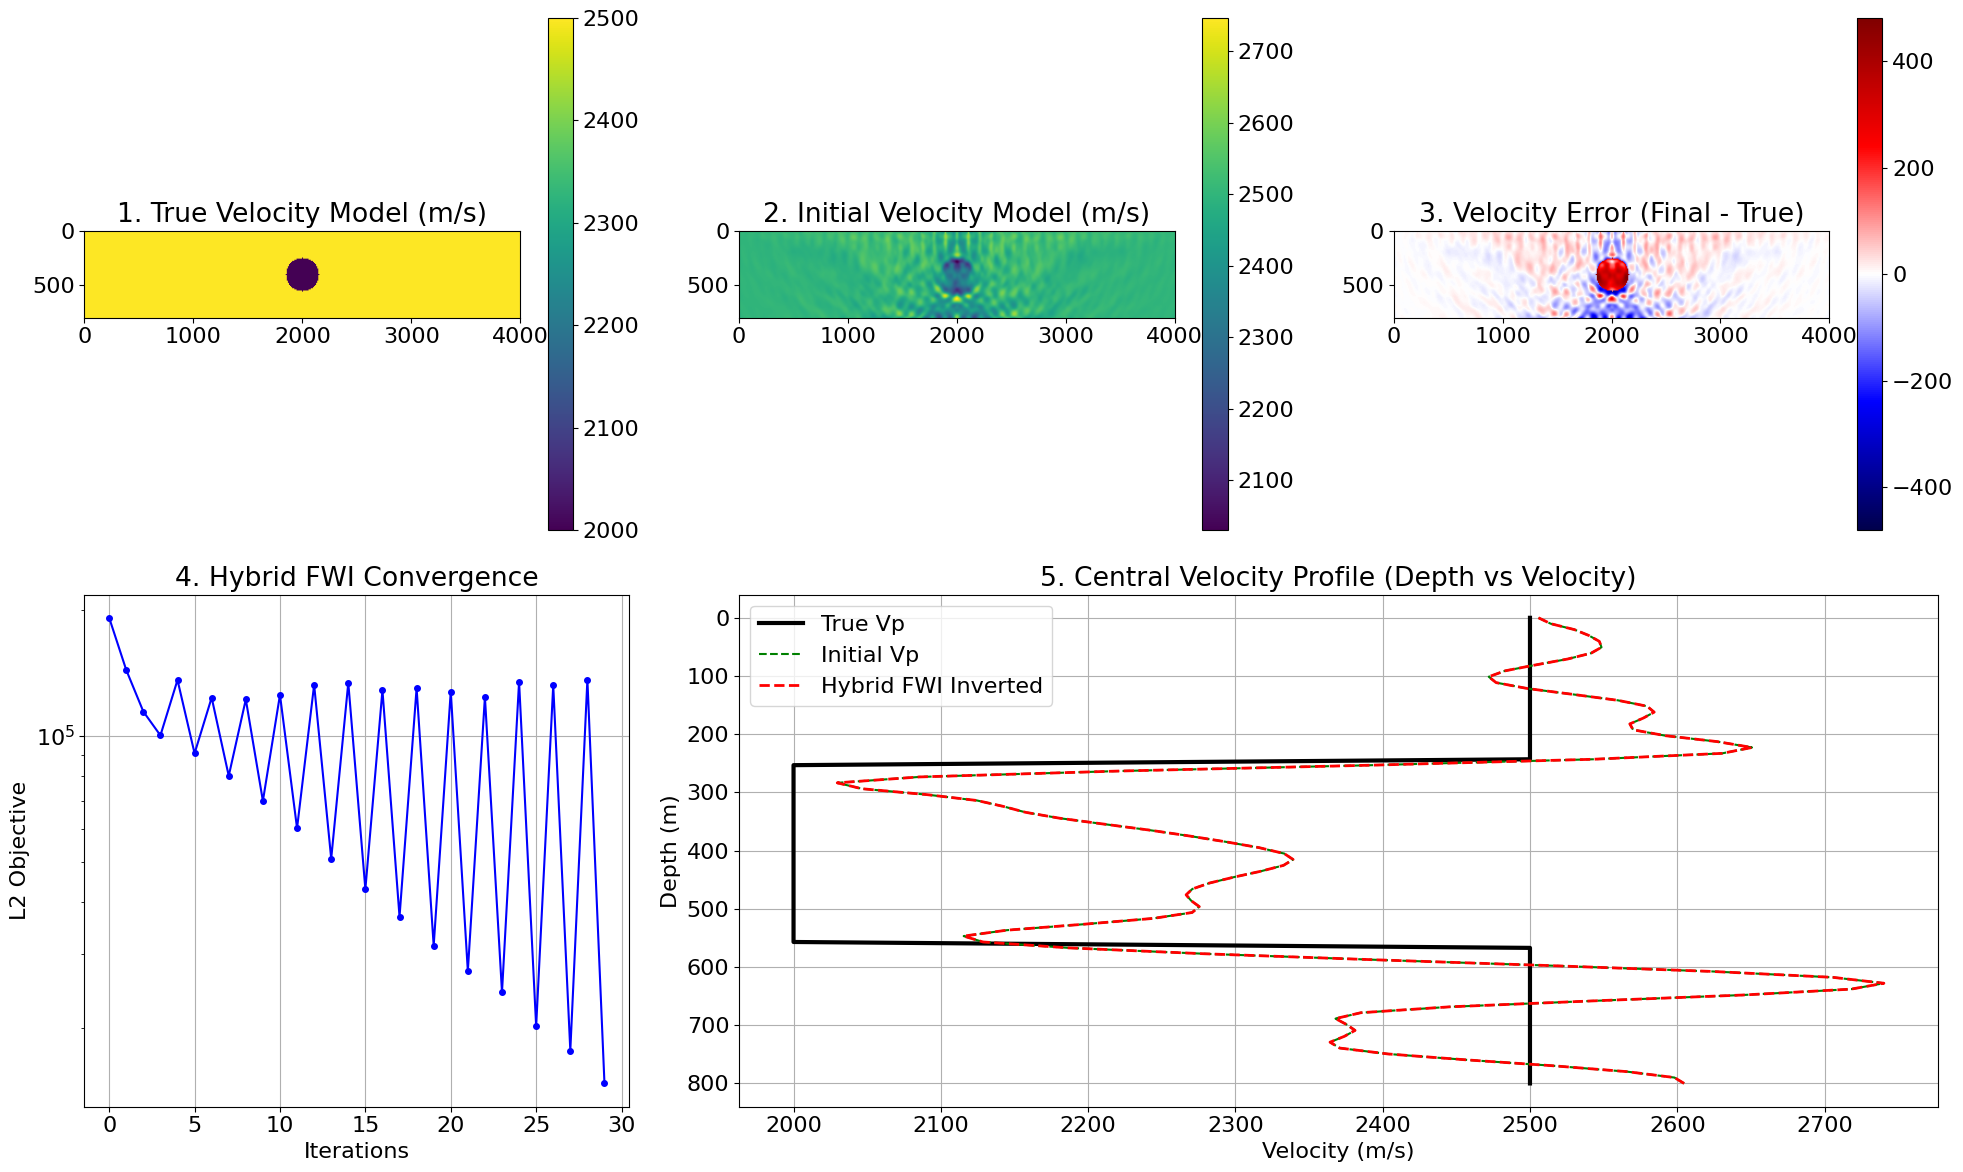

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# Set Devito environment for Colab
os.environ['DEVITO_ARCH'] = 'gcc'
from devito import configuration, Function, Eq, Operator, norm, Min, Max
from examples.seismic import Model, AcquisitionGeometry, Receiver
from examples.seismic.acoustic import AcousticWaveSolver

# Qiskit Imports
from qiskit import QuantumCircuit
from qiskit.circuit.library import RealAmplitudes, ZZFeatureMap
from qiskit_aer import Aer
from qiskit_machine_learning.neural_networks import EstimatorQNN

# Silence Devito logging
configuration['log-level'] = 'WARNING'

# ------------------ 1. Setup: Grid & Models --------------------
nx, nz = 400, 80  # Slightly adjusted for efficiency
shape = (nx, nz)
spacing = (10., 10.)
origin = (0., 0.)
nbl = 20

v0, v_anomaly = 2.5, 2.0 # km/s

# True Model
velocity_true = np.full(shape, v0, dtype=np.float32)
cx, cz = nx // 2, nz // 2
radius = 15
for i in range(nx):
    for j in range(nz):
        if (i - cx)**2 + (j - cz)**2 <= radius**2:
            velocity_true[i, j] = v_anomaly

model_true = Model(vp=velocity_true, origin=origin, shape=shape, spacing=spacing,
                   nbl=nbl, space_order=4, bcs="damp")

# Initial Model
velocity_init = np.full(shape, v0, dtype=np.float32)
model0 = Model(vp=velocity_init, origin=origin, shape=shape, spacing=spacing,
               nbl=nbl, space_order=4, bcs="damp")

# ------------------ 2. Quantum Optimizer (Qiskit) --------------
num_qubits = 2
feature_map = ZZFeatureMap(num_qubits)
ansatz = RealAmplitudes(num_qubits, reps=1)
qc = QuantumCircuit(num_qubits)
qc.compose(feature_map, inplace=True)
qc.compose(ansatz, inplace=True)

# Quantum Neural Network to adaptively scale the FWI gradient update
qnn = EstimatorQNN(circuit=qc, input_params=feature_map.parameters, weight_params=ansatz.parameters)

def quantum_step_optimizer(grad_data, weights):
    """Uses Quantum Circuit to find an optimal scaling factor based on gradient statistics."""
    # Extract features from the classical gradient
    mean_g = np.mean(grad_data)
    std_g = np.std(grad_data) + 1e-6
    inputs = np.array([(mean_g/std_g)] * num_qubits)

    # Run Quantum Simulator (Aer)
    q_output = qnn.forward(inputs, weights)
    return np.mean(q_output)

# ------------------ 3. FWI Helper Functions -------------------
nshots, nreceivers = 20, 150
t0, tn = 0.0, 1200.0
src_coords = np.empty((nshots, 2))
src_coords[:, 0] = np.linspace(0, model_true.domain_size[0], num=nshots)
src_coords[:, 1] = 20.
rec_coords = np.empty((nreceivers, 2))
rec_coords[:, 0] = np.linspace(0, model_true.domain_size[0], num=nreceivers)
rec_coords[:, 1] = 20.

def fwi_gradient(vp_in, model_true, geometry, solver):
    grad = Function(name="grad", grid=vp_in.grid)
    d_obs = Receiver(name='d_obs', grid=vp_in.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)
    d_syn = Receiver(name='d_syn', grid=vp_in.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)
    residual = Receiver(name='res', grid=vp_in.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)

    obj = 0.
    for i in range(nshots):
        geometry.src_positions[0, :] = src_coords[i, :]
        solver.forward(vp=model_true.vp, rec=d_obs)
        _, u0, _ = solver.forward(vp=vp_in, save=True, rec=d_syn)
        residual.data[:] = d_syn.data[:] - d_obs.data[:]
        obj += .5 * norm(residual)**2
        solver.gradient(rec=residual, u=u0, vp=vp_in, grad=grad)
    return obj, grad

# ------------------ 4. Hybrid Execution Loop -------------------
iterations = 30
f0 = 0.012 # 12 Hz
geometry = AcquisitionGeometry(model_true, rec_coords, src_coords, t0=t0, tn=tn, f0=f0, src_type='Ricker')
solver = AcousticWaveSolver(model_true, geometry, space_order=4)
history = []
q_weights = np.random.rand(qnn.num_weights) # Variational params for Quantum Circuit

vp_curr = model0.vp
slice_core = (slice(nbl, -nbl), slice(nbl, -nbl))

print("--- Starting Hybrid Quantum-Classical FWI ---")
for it in range(iterations):
    phi, grad = fwi_gradient(vp_curr, model_true, geometry, solver)
    history.append(phi)

    # 1. Classical Gradient Pre-processing
    grad_data = grad.data[slice_core]
    smooth_grad = gaussian_filter(grad_data, sigma=1.2)

    # 2. Quantum Step Refinement
    # Passing a slice of the gradient around the anomaly center to the Quantum Circuit
    q_mod = quantum_step_optimizer(smooth_grad[cx-20:cx+20, cz-20:cz+20], q_weights)

    # 3. Hybrid Update
    # Base alpha scaled by Quantum Modifier
    alpha = (0.05 / (np.max(np.abs(smooth_grad)) + 1e-9)) * (1.0 + 0.1 * q_mod)
    update_eq = Eq(vp_curr, Max(Min(vp_curr + alpha * grad, 3.0), 1.5))
    Operator(update_eq)()

    # Update Quantum Variational Weights (Heuristic shift)
    q_weights += 0.01 * q_mod

    if it % 5 == 0:
        print(f"Iteration {it:02d} | Objective: {phi:.4e} | Quantum Modifier: {q_mod:.4f}")

# ------------------ 5. Final Visualization --------------------------
vp_final = vp_curr.data[slice_core] * 1000.0
vp_initial = model0.vp.data[slice_core] * 1000.0
vp_true_data = model_true.vp.data[slice_core] * 1000.0
error = vp_final - vp_true_data
depth = np.linspace(0, nz * spacing[1], vp_final.shape[1])
mid_x = vp_final.shape[0] // 2
extent = [0, nx*spacing[0], nz*spacing[1], 0]

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 3)

# 1. True Model
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(vp_true_data.T, cmap='viridis', extent=extent)
ax1.set_title("1. True Velocity Model (m/s)")
plt.colorbar(im1, ax=ax1)

# 2. Initial Model
ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(vp_initial.T, cmap='viridis', extent=extent)
ax2.set_title("2. Initial Velocity Model (m/s)")
plt.colorbar(im2, ax=ax2)

# 3. Velocity Error
ax3 = fig.add_subplot(gs[0, 2])
max_err = np.max(np.abs(error))
im3 = ax3.imshow(error.T, cmap='seismic', extent=extent, vmin=-max_err, vmax=max_err)
ax3.set_title("3. Velocity Error (Final - True)")
plt.colorbar(im3, ax=ax3)

# 4. Convergence Curve
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(history, 'b-o', markersize=4)
ax4.set_yscale('log')
ax4.set_title("4. Hybrid FWI Convergence")
ax4.set_xlabel("Iterations")
ax4.set_ylabel("L2 Objective")
ax4.grid(True)

# 5. Velocity Profile
ax5 = fig.add_subplot(gs[1, 1:])
ax5.plot(vp_true_data[mid_x, :], depth, 'k-', linewidth=3, label='True Vp')
ax5.plot(vp_initial[mid_x, :], depth, 'g--', label='Initial Vp')
ax5.plot(vp_final[mid_x, :], depth, 'r--', linewidth=2, label='Hybrid FWI Inverted')
ax5.invert_yaxis()
ax5.set_title(f"5. Central Velocity Profile (Depth vs Velocity)")
ax5.set_xlabel("Velocity (m/s)")
ax5.set_ylabel("Depth (m)")
ax5.legend()
ax5.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# Set Devito environment for Colab
os.environ['DEVITO_ARCH'] = 'gcc'
from devito import configuration, Function, Eq, Operator, norm, Min, Max
from examples.seismic import Model, AcquisitionGeometry, Receiver
from examples.seismic.acoustic import AcousticWaveSolver

# Qiskit Imports
from qiskit import QuantumCircuit
from qiskit.circuit.library import RealAmplitudes, ZZFeatureMap
from qiskit_machine_learning.neural_networks import EstimatorQNN

# Silence Devito logging
configuration['log-level'] = 'WARNING'

# ------------------ 1. Setup: Grid & True / Initial Models --------------------
nx, nz = 500, 80
shape = (nx, nz)
spacing = (10., 10.)
origin = (0., 0.)
nbl = 20

v0, v_anomaly = 2.5, 2.0  # Background and Fluid pocket (km/s)

# Create the true velocity grid (Circular Anomaly)
velocity_true = np.full(shape, v0, dtype=np.float32)
cx, cz = nx // 2, nz // 2
radius = 15
for i in range(nx):
    for j in range(nz):
        if (i - cx)**2 + (j - cz)**2 <= radius**2:
            velocity_true[i, j] = v_anomaly

model_true = Model(vp=velocity_true, origin=origin, shape=shape, spacing=spacing,
                   nbl=nbl, space_order=4, bcs="damp")

# Initial Model (Constant Background)
velocity_init = np.full(shape, v0, dtype=np.float32)
model0 = Model(vp=velocity_init, origin=origin, shape=shape, spacing=spacing,
               nbl=nbl, space_order=4, bcs="damp")

# ------------------ 2. Quantum Optimizer Setup -----------------
num_qubits = 2
qc = QuantumCircuit(num_qubits)
qc.compose(ZZFeatureMap(num_qubits), inplace=True)
qc.compose(RealAmplitudes(num_qubits, reps=1), inplace=True)

# QNN to analyze the gradient and output a step-size correction factor
qnn = EstimatorQNN(circuit=qc, input_params=qc.parameters[:num_qubits], weight_params=qc.parameters[num_qubits:])
q_weights = np.random.rand(qnn.num_weights)

def get_quantum_alpha(grad_segment, weights, base_alpha):
    """Refines the step size (alpha) using a Quantum Neural Network."""
    # Normalize features for QNN input
    feature = np.mean(grad_segment) / (np.std(grad_segment) + 1e-9)
    inputs = np.array([feature] * num_qubits)
    q_out = qnn.forward(inputs, weights)
    # Quantum modifier ranges roughly from 0.9 to 1.1 (nudges the learning rate)
    modifier = 1.0 + 0.1 * np.mean(q_out)
    return base_alpha * modifier

# ------------------ 3. Acquisition Geometry -----------------------
nshots = 35
nreceivers = 250
t0, tn = 0.0, 1500.0

src_coords = np.empty((nshots, 2))
src_coords[:, 0] = np.linspace(0, model_true.domain_size[0], num=nshots)
src_coords[:, 1] = 20.

rec_coords = np.empty((nreceivers, 2))
rec_coords[:, 0] = np.linspace(0, model_true.domain_size[0], num=nreceivers)
rec_coords[:, 1] = 20.

# ------------------ 4. Multiscale Hybrid Execution -----------------
# 3Hz is critical for the "big picture", 15Hz for sharp edges
frequencies = [0.003, 0.008, 0.015]
iterations = [40, 30, 20]
history = []
vp_curr = model0.vp
slice_core = (slice(nbl, -nbl), slice(nbl, -nbl))

print("--- Starting Improved Multiscale Hybrid Quantum FWI ---")
for f_idx, f0 in enumerate(frequencies):
    print(f"\n>> Stage {f_idx+1}: frequency {f0*1000} Hz")
    geometry = AcquisitionGeometry(model_true, rec_coords, src_coords, t0=t0, tn=tn, f0=f0, src_type='Ricker')
    solver = AcousticWaveSolver(model_true, geometry, space_order=4)

    for it in range(iterations[f_idx]):
        # Classical Gradient Calculation
        grad = Function(name="grad", grid=vp_curr.grid)
        d_obs = Receiver(name='d_obs', grid=vp_curr.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)
        d_syn = Receiver(name='d_syn', grid=vp_curr.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)
        res = Receiver(name='res', grid=vp_curr.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)

        obj = 0.
        for i in range(nshots):
            geometry.src_positions[0, :] = src_coords[i, :]
            solver.forward(vp=model_true.vp, rec=d_obs)
            _, u0, _ = solver.forward(vp=vp_curr, save=True, rec=d_syn)
            res.data[:] = d_syn.data[:] - d_obs.data[:]
            obj += .5 * norm(res)**2
            solver.gradient(rec=res, u=u0, vp=vp_curr, grad=grad)

        history.append(obj)

        # Gradient Processing
        actual_grad = grad.data[slice_core]
        max_g = np.max(np.abs(actual_grad))
        base_alpha = (0.08 if f_idx == 0 else 0.05) / (max_g + 1e-9)

        # Hybrid Step: Use Quantum Circuit to optimize Alpha
        # We pass the central region (the anomaly area) to the Quantum Optimizer
        alpha = get_quantum_alpha(actual_grad[cx-20:cx+20, :], q_weights, base_alpha)

        # Apply Update (Classical Wavefield Update)
        update_eq = Eq(vp_curr, Max(Min(vp_curr + alpha * grad, 3.0), 1.5))
        Operator(update_eq)()

        # Heuristic Quantum Weight Update
        q_weights += 0.01 * (alpha / base_alpha - 1.0)

        if it % 10 == 0:
            print(f"   Iteration {it+1}/{iterations[f_idx]} | Objective: {obj:.4e}")

print("\n--- Hybrid FWI Completed ---")

# ------------------ 5. Visualization ---------------------
vp_final = vp_curr.data[slice_core] * 1000.0
vp_initial = model0.vp.data[slice_core] * 1000.0
vp_true_data = model_true.vp.data[slice_core] * 1000.0
velocity_error = vp_final - vp_true_data
depth = np.linspace(0, nz * spacing[1], nz)
mid_x = nx // 2
extent = [0, nx*spacing[0], nz*spacing[1], 0]

fig = plt.figure(figsize=(22, 12))
gs = fig.add_gridspec(2, 3)

# 1. True Model
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(vp_true_data.T, cmap='viridis', extent=extent)
ax1.set_title("1. True Velocity Model (m/s)")
plt.colorbar(im1, ax=ax1)

# 2. Initial Model
ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(vp_initial.T, cmap='viridis', extent=extent)
ax2.set_title("2. Initial Velocity Model (m/s)")
plt.colorbar(im2, ax=ax2)

# 3. Inverted (Hybrid) Model
ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.imshow(vp_final.T, cmap='viridis', extent=extent)
ax3.set_title("3. Hybrid FWI Inverted Model (m/s)")
plt.colorbar(im3, ax=ax3)

# 4. Velocity Error
ax4 = fig.add_subplot(gs[1, 0])
max_err = np.max(np.abs(velocity_error))
im4 = ax4.imshow(velocity_error.T, cmap='seismic', extent=extent, vmin=-max_err, vmax=max_err)
ax4.set_title("4. Velocity Error (Inverted - True)")
plt.colorbar(im4, ax=ax4)

# 5. Convergence Curve
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(history, 'b-', linewidth=2)
ax5.set_yscale('log')
ax5.set_title("5. Hybrid FWI Convergence")
ax5.set_xlabel("Total Iterations")
ax5.grid(True)

# 6. Velocity Profile
ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(vp_true_data[mid_x, :], depth, 'k-', linewidth=3, label='True Vp')
ax6.plot(vp_initial[mid_x, :], depth, 'g--', label='Initial Vp')
ax6.plot(vp_final[mid_x, :], depth, 'r--', linewidth=2, label='Hybrid FWI')
ax6.invert_yaxis()
ax6.set_title("6. Central Velocity Profile")
ax6.set_xlabel("Velocity (m/s)")
ax6.set_ylabel("Depth (m)")
ax6.legend()
ax6.grid(True)

plt.tight_layout()
plt.show()

--- Starting Multiscale Hybrid ADAM FWI ---

>> Stage 1: frequency 3.0 Hz
   Iteration 1/40 | Obj: 7.6375e+06 | Q-LR Mod: 1.033
   Iteration 11/40 | Obj: 2.9056e+06 | Q-LR Mod: 1.026
   Iteration 21/40 | Obj: 1.9211e+06 | Q-LR Mod: 1.032
   Iteration 31/40 | Obj: 1.1806e+06 | Q-LR Mod: 1.018

>> Stage 2: frequency 8.0 Hz
   Iteration 1/30 | Obj: 1.0210e+06 | Q-LR Mod: 1.033
   Iteration 11/30 | Obj: 7.4955e+05 | Q-LR Mod: 1.032
   Iteration 21/30 | Obj: 5.3567e+05 | Q-LR Mod: 1.029

>> Stage 3: frequency 15.0 Hz
   Iteration 1/20 | Obj: 4.7096e+05 | Q-LR Mod: 0.985
   Iteration 11/20 | Obj: 2.2146e+05 | Q-LR Mod: 1.024


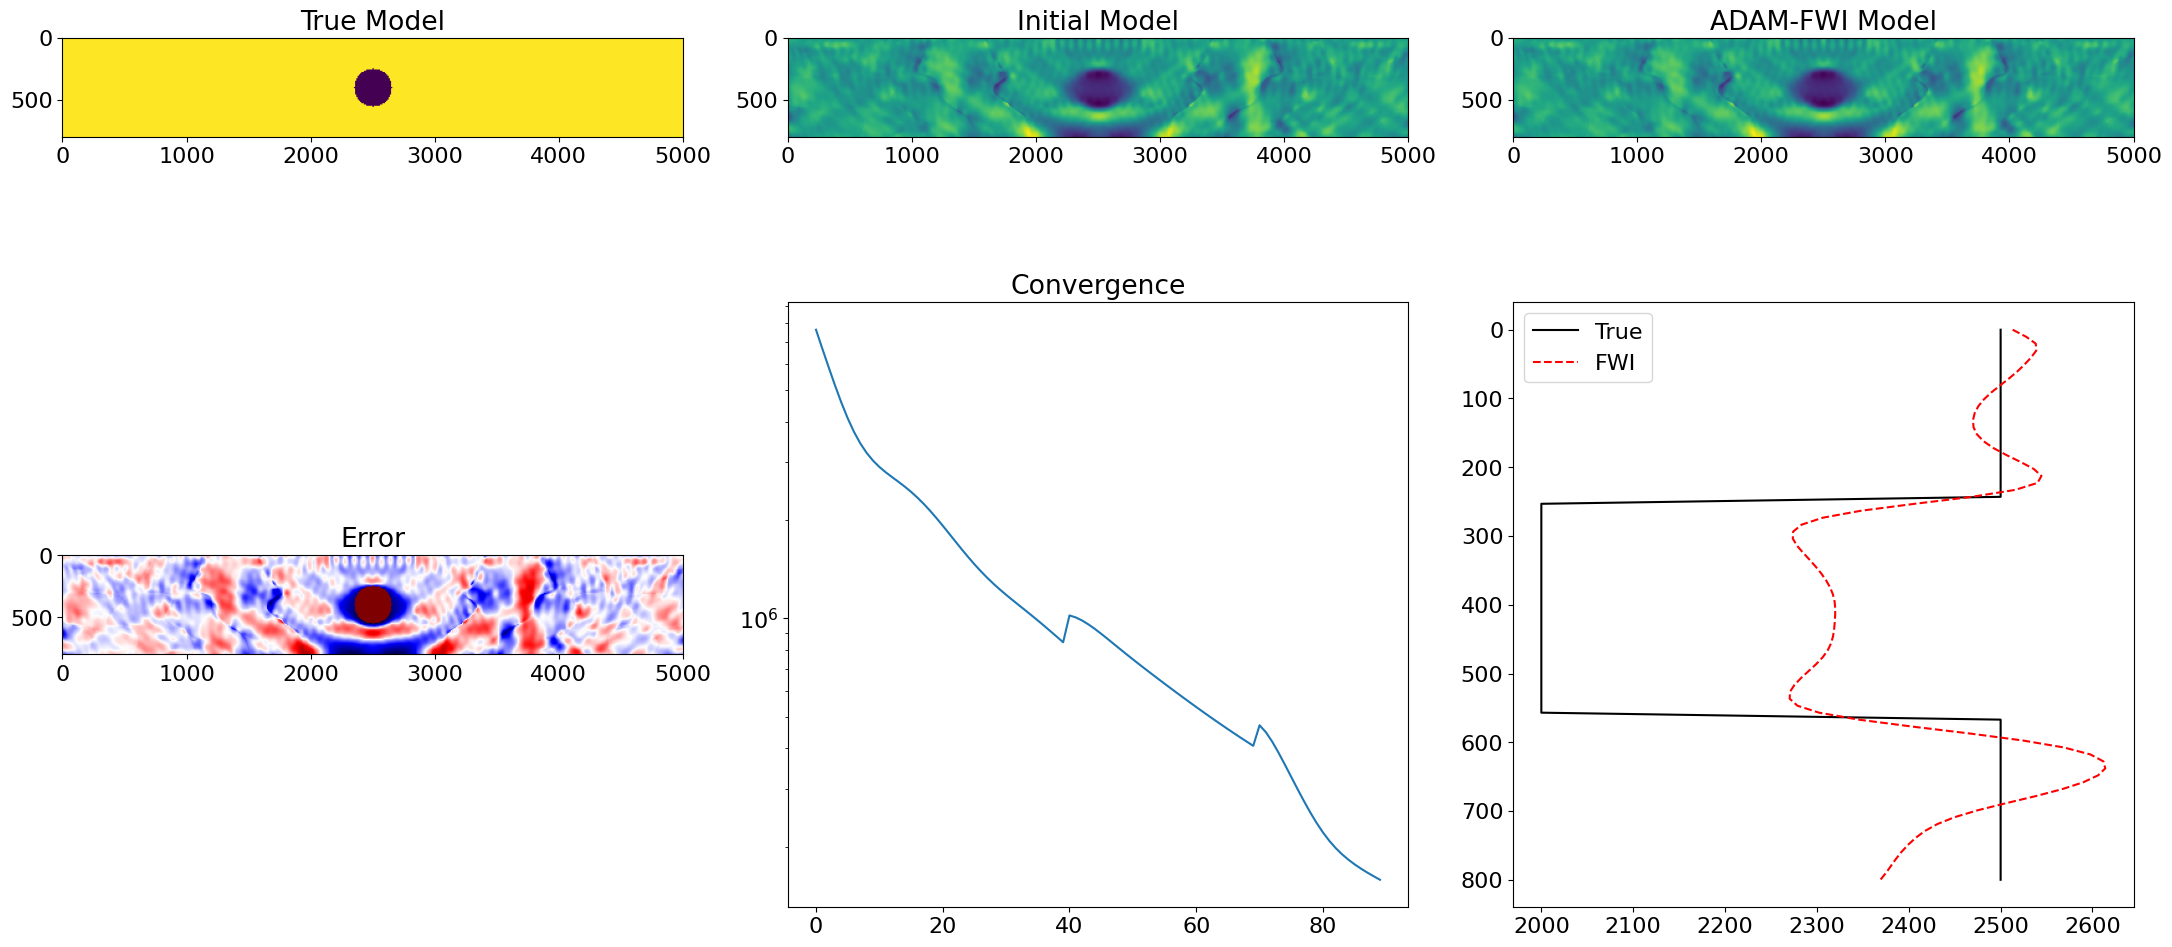

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# Set Devito environment for Colab
os.environ['DEVITO_ARCH'] = 'gcc'
from devito import configuration, Function, Eq, Operator, norm, Min, Max
from examples.seismic import Model, AcquisitionGeometry, Receiver
from examples.seismic.acoustic import AcousticWaveSolver

# Updated Qiskit Imports (Addressing Deprecation Warnings)
from qiskit.circuit.library import zz_feature_map, real_amplitudes
from qiskit_machine_learning.neural_networks import EstimatorQNN

# Silence Devito logging
configuration['log-level'] = 'WARNING'

# ------------------ 1. Setup: Grid & Models --------------------
nx, nz = 500, 80
shape = (nx, nz)
spacing = (10., 10.)
origin = (0., 0.)
nbl = 20  # Neighbor Boundary Layer

v0, v_anomaly = 2.5, 2.0

velocity_true = np.full(shape, v0, dtype=np.float32)
cx, cz = nx // 2, nz // 2
radius = 15
for i in range(nx):
    for j in range(nz):
        if (i - cx)**2 + (j - cz)**2 <= radius**2:
            velocity_true[i, j] = v_anomaly

model_true = Model(vp=velocity_true, origin=origin, shape=shape, spacing=spacing,
                   nbl=nbl, space_order=4, bcs="damp")
model0 = Model(vp=np.full(shape, v0, dtype=np.float32), origin=origin, shape=shape,
               spacing=spacing, nbl=nbl, space_order=4, bcs="damp")

# ------------------ 2. Quantum Optimizer Setup -----------------
num_qubits = 2
# Using the new functional approach to avoid DeprecationWarnings
feature_map = zz_feature_map(num_qubits)
ansatz = real_amplitudes(num_qubits, reps=1)
qc = feature_map.compose(ansatz)

qnn = EstimatorQNN(circuit=qc, input_params=feature_map.parameters, weight_params=ansatz.parameters)
q_weights = np.random.rand(qnn.num_weights)

def get_quantum_alpha_modifier(grad_data, weights):
    stat_feature = np.mean(np.abs(grad_data)) / (np.std(grad_data) + 1e-9)
    inputs = np.array([stat_feature] * num_qubits)
    q_out = qnn.forward(inputs, weights)
    return 1.0 + 0.1 * np.mean(q_out)

# ------------------ 3. Acquisition Geometry -------------------
nshots, nreceivers = 35, 250
t0, tn = 0.0, 1500.0
src_coords = np.empty((nshots, 2))
src_coords[:, 0] = np.linspace(0, model_true.domain_size[0], num=nshots)
src_coords[:, 1] = 20.
rec_coords = np.empty((nreceivers, 2))
rec_coords[:, 0] = np.linspace(0, model_true.domain_size[0], num=nreceivers)
rec_coords[:, 1] = 20.

# ------------------ 4. ADAM Initialization (CORRECTED SHAPE) ----------------
# We must use model0.vp.data.shape to include the padding (nbl)
padded_shape = model0.vp.data.shape
m = np.zeros(padded_shape, dtype=np.float32)
v = np.zeros(padded_shape, dtype=np.float32)
beta1, beta2 = 0.9, 0.999
epsilon = 1e-8
adam_t = 0

# ------------------ 5. Multiscale ADAM Hybrid FWI -------------
frequencies = [0.003, 0.008, 0.015]
iterations = [40, 30, 20]
history = []
vp_curr = model0.vp
# Slice to ignore boundaries for visualization/quantum metrics
slice_core = (slice(nbl, -nbl), slice(nbl, -nbl))

print("--- Starting Multiscale Hybrid ADAM FWI ---")
for f_idx, f0 in enumerate(frequencies):
    print(f"\n>> Stage {f_idx+1}: frequency {f0*1000} Hz")
    geometry = AcquisitionGeometry(model_true, rec_coords, src_coords, t0=t0, tn=tn, f0=f0, src_type='Ricker')
    solver = AcousticWaveSolver(model_true, geometry, space_order=4)
    base_lr = 0.005 if f_idx == 0 else 0.003

    for it in range(iterations[f_idx]):
        adam_t += 1
        grad = Function(name="grad", grid=vp_curr.grid)
        d_obs = Receiver(name='d_obs', grid=vp_curr.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)
        d_syn = Receiver(name='d_syn', grid=vp_curr.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)
        res = Receiver(name='res', grid=vp_curr.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)

        # 1. Classical Physics
        obj = 0.
        for i in range(nshots):
            geometry.src_positions[0, :] = src_coords[i, :]
            solver.forward(vp=model_true.vp, rec=d_obs)
            _, u0, _ = solver.forward(vp=vp_curr, save=True, rec=d_syn)
            res.data[:] = d_syn.data[:] - d_obs.data[:]
            obj += .5 * norm(res)**2
            solver.gradient(rec=res, u=u0, vp=vp_curr, grad=grad)

        history.append(obj)

        # 2. Gradient Processing
        g_data = grad.data[:] # This is (540, 120)
        # Apply Gaussian filter to the full padded gradient
        g_data = gaussian_filter(g_data, sigma=1.0)

        # 3. ADAM Update Logic (Shapes now match: 540x120)
        m = beta1 * m + (1 - beta1) * g_data
        v = beta2 * v + (1 - beta2) * (g_data**2)

        m_hat = m / (1 - beta1**adam_t)
        v_hat = v / (1 - beta2**adam_t)

        # 4. Quantum Refinement
        q_mod = get_quantum_alpha_modifier(g_data[slice_core], q_weights)
        current_lr = base_lr * q_mod

        # 5. Apply Update
        update_step = current_lr * m_hat / (np.sqrt(v_hat) + epsilon)
        vp_curr.data[:] = np.clip(vp_curr.data[:] + update_step, 1.5, 3.0)

        if it % 10 == 0:
            print(f"   Iteration {it+1}/{iterations[f_idx]} | Obj: {obj:.4e} | Q-LR Mod: {q_mod:.3f}")

# ------------------ 6. Visualization --------------------------
# Slicing the final data to remove the nbl padding for plotting
vp_final = vp_curr.data[slice_core] * 1000.0
vp_initial = model0.vp.data[slice_core] * 1000.0
vp_true_data = model_true.vp.data[slice_core] * 1000.0
error = vp_final - vp_true_data
depth = np.linspace(0, nz * spacing[1], nz)
extent = [0, nx*spacing[0], nz*spacing[1], 0]

fig, ax = plt.subplots(2, 3, figsize=(22, 12))
# (Plotting code remains the same as before...)
im1 = ax[0,0].imshow(vp_true_data.T, cmap='viridis', extent=extent); ax[0,0].set_title("True Model")
im2 = ax[0,1].imshow(vp_initial.T, cmap='viridis', extent=extent); ax[0,1].set_title("Initial Model")
im3 = ax[0,2].imshow(vp_final.T, cmap='viridis', extent=extent); ax[0,2].set_title("ADAM-FWI Model")
im4 = ax[1,0].imshow(error.T, cmap='seismic', extent=extent, vmin=-200, vmax=200); ax[1,0].set_title("Error")
ax[1,1].plot(history); ax[1,1].set_yscale('log'); ax[1,1].set_title("Convergence")
ax[1,2].plot(vp_true_data[nx//2, :], depth, 'k', label='True')
ax[1,2].plot(vp_final[nx//2, :], depth, 'r--', label='FWI')
ax[1,2].invert_yaxis(); ax[1,2].legend()
plt.tight_layout(); plt.show()

--- Starting Hybrid ADAM FWI ---

>> Stage 1: frequency 3.0 Hz
   Iteration 00 | Obj: 7.638e+06 | Q-Mod: 0.951
   Iteration 10 | Obj: 2.784e+06 | Q-Mod: 0.945
   Iteration 20 | Obj: 1.507e+06 | Q-Mod: 0.928
   Iteration 30 | Obj: 8.797e+05 | Q-Mod: 0.928
   Iteration 40 | Obj: 4.905e+05 | Q-Mod: 0.928
   Iteration 50 | Obj: 2.880e+05 | Q-Mod: 0.936

>> Stage 2: frequency 7.0 Hz
   Iteration 00 | Obj: 1.048e+06 | Q-Mod: 0.987
   Iteration 10 | Obj: 6.478e+05 | Q-Mod: 0.949
   Iteration 20 | Obj: 3.988e+05 | Q-Mod: 0.936
   Iteration 30 | Obj: 2.552e+05 | Q-Mod: 0.932

>> Stage 3: frequency 12.0 Hz
   Iteration 00 | Obj: 2.132e+05 | Q-Mod: 0.938
   Iteration 10 | Obj: 1.129e+05 | Q-Mod: 0.940
   Iteration 20 | Obj: 9.148e+04 | Q-Mod: 0.961


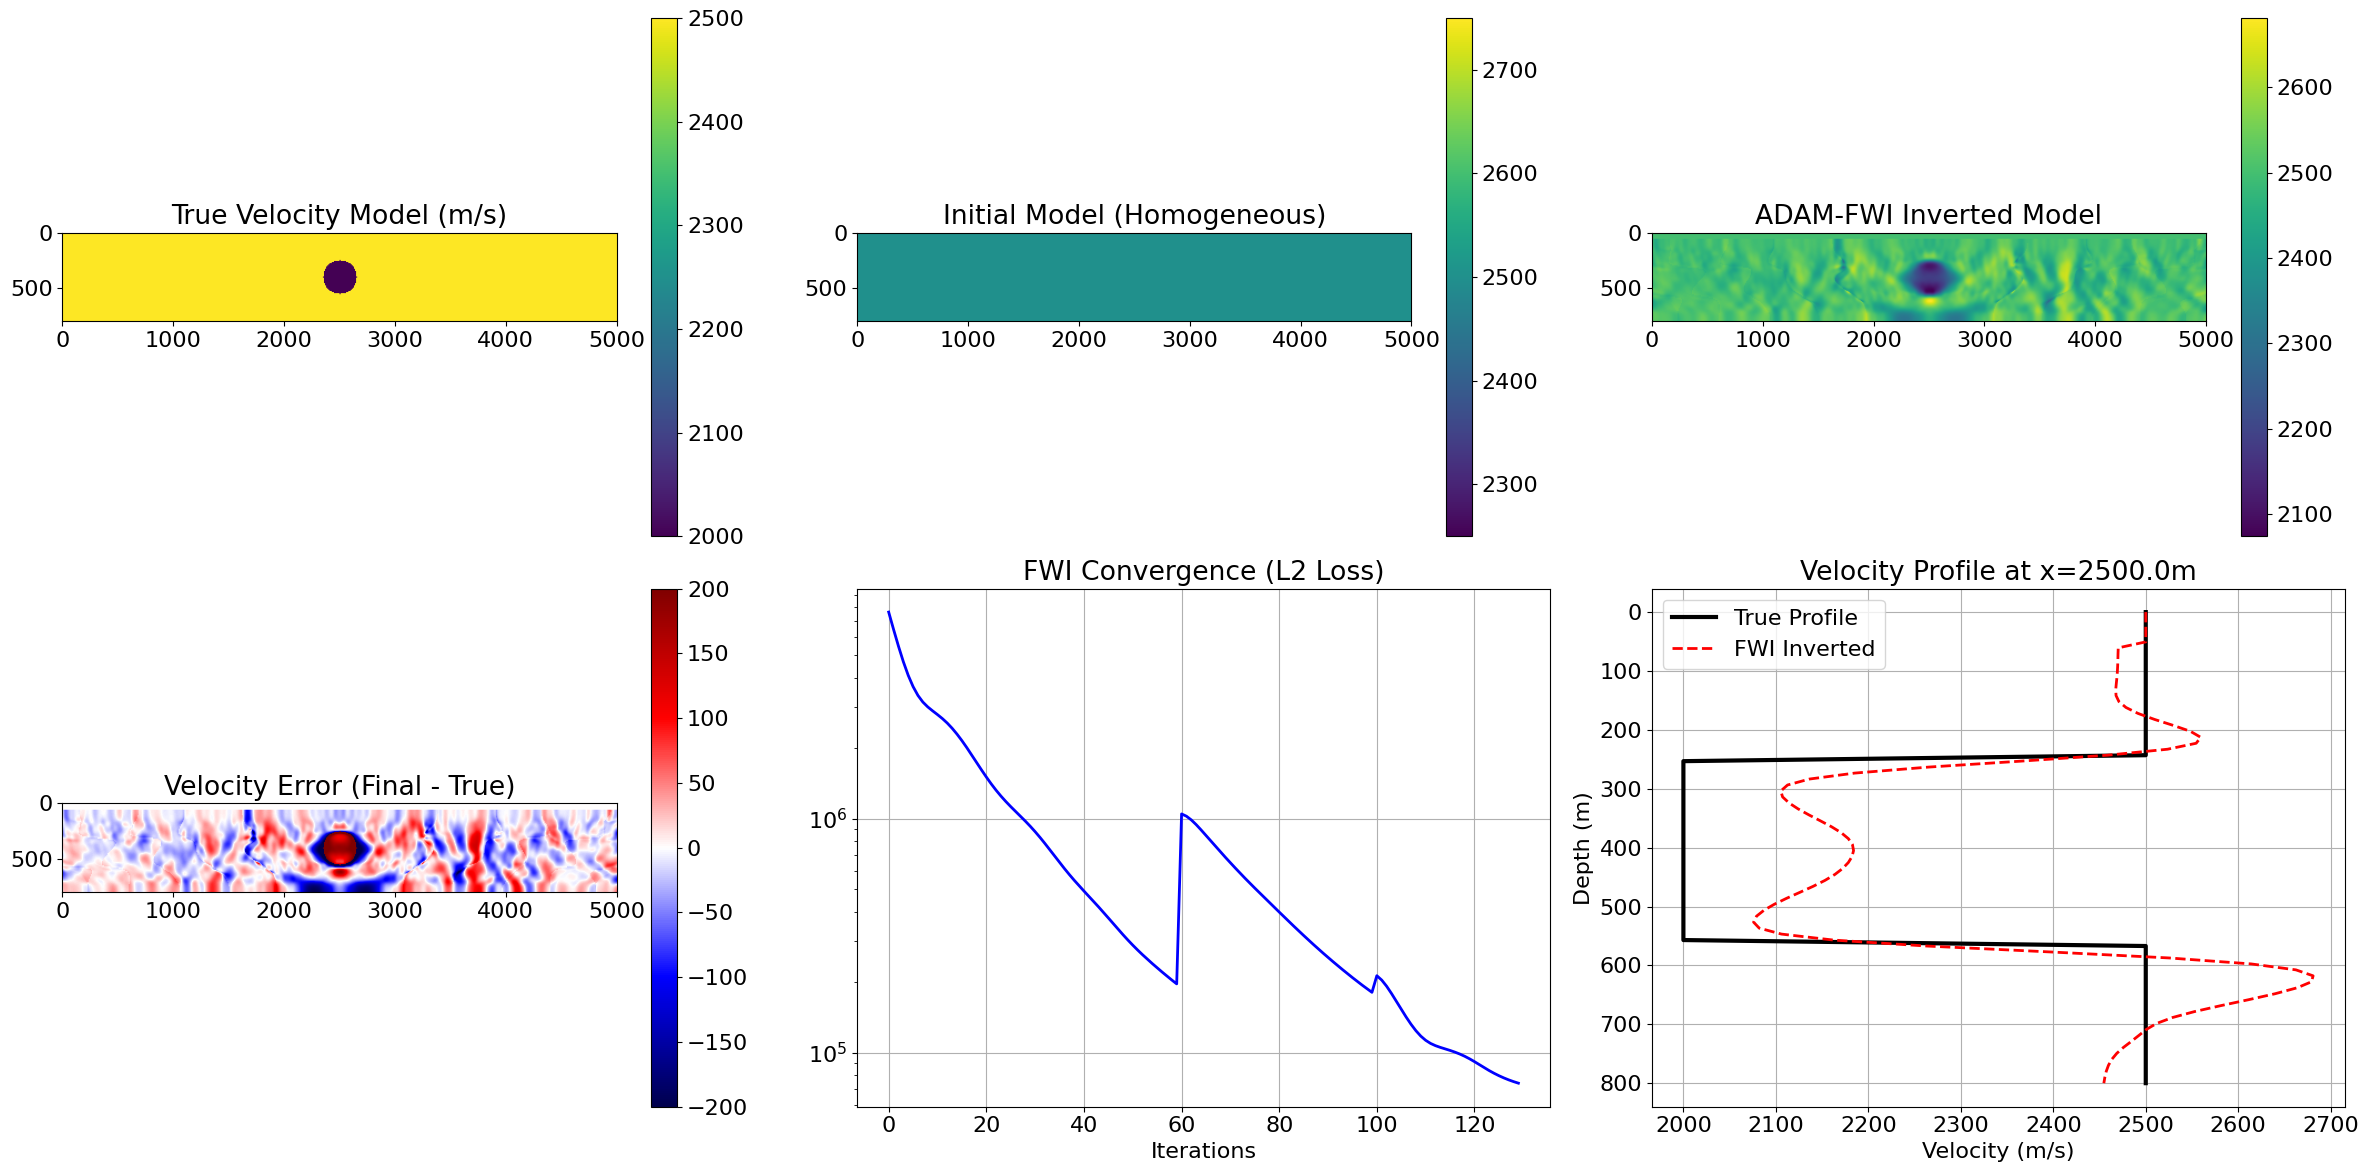

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# Devito configuration for Colab
os.environ['DEVITO_ARCH'] = 'gcc'
from devito import configuration, Function, Eq, Operator, norm, Min, Max
from examples.seismic import Model, AcquisitionGeometry, Receiver
from examples.seismic.acoustic import AcousticWaveSolver

# Qiskit updated imports
from qiskit.circuit.library import zz_feature_map, real_amplitudes
from qiskit_machine_learning.neural_networks import EstimatorQNN

configuration['log-level'] = 'WARNING'

# ------------------ 1. Setup: Grid & Models --------------------
nx, nz = 500, 80
shape = (nx, nz)
spacing = (10., 10.)
origin = (0., 0.)
nbl = 20

v0, v_anomaly = 2.5, 2.0  # Background 2500m/s, Anomaly 2000m/s

# True Model: Background with a circular low-velocity anomaly
velocity_true = np.full(shape, v0, dtype=np.float32)
cx, cz = nx // 2, nz // 2
radius = 15
for i in range(nx):
    for j in range(nz):
        if (i - cx)**2 + (j - cz)**2 <= radius**2:
            velocity_true[i, j] = v_anomaly

model_true = Model(vp=velocity_true, origin=origin, shape=shape, spacing=spacing,
                   nbl=nbl, space_order=4, bcs="damp")

# Initial Model: Strictly Homogeneous (Constant 2500 m/s)
velocity_init = np.full(shape, v0, dtype=np.float32)
model0 = Model(vp=velocity_init, origin=origin, shape=shape, spacing=spacing,
               nbl=nbl, space_order=4, bcs="damp")

# ------------------ 2. Quantum Optimizer Setup -----------------
num_qubits = 2
fmap = zz_feature_map(num_qubits)
ansatz = real_amplitudes(num_qubits, reps=1)
qc = fmap.compose(ansatz)
qnn = EstimatorQNN(circuit=qc, input_params=fmap.parameters, weight_params=ansatz.parameters)
q_weights = np.random.rand(qnn.num_weights)

def get_quantum_modifier(grad_data, weights):
    # Pass a statistical feature of the gradient to the Quantum Circuit
    feature = np.mean(np.abs(grad_data)) / (np.std(grad_data) + 1e-9)
    inputs = np.array([feature] * num_qubits)
    q_out = qnn.forward(inputs, weights)
    return 1.0 + 0.1 * np.mean(q_out)

# ------------------ 3. Acquisition Geometry -------------------
nshots, nreceivers = 35, 250
t0, tn = 0.0, 1500.0
src_coords = np.empty((nshots, 2))
src_coords[:, 0] = np.linspace(0, model_true.domain_size[0], num=nshots)
src_coords[:, 1] = 20.  # Source depth
rec_coords = np.empty((nreceivers, 2))
rec_coords[:, 0] = np.linspace(0, model_true.domain_size[0], num=nreceivers)
rec_coords[:, 1] = 20.  # Receiver depth

# ------------------ 4. ADAM Buffers (Padded Shapes) -----------
padded_shape = model0.vp.data.shape
m = np.zeros(padded_shape, dtype=np.float32)
v = np.zeros(padded_shape, dtype=np.float32)
beta1, beta2 = 0.9, 0.999
epsilon = 1e-8
adam_t = 0

# ------------------ 5. Multiscale FWI Loop --------------------
frequencies = [0.003, 0.007, 0.012] # Low-to-mid frequency strategy
iterations = [60, 40, 30]
history = []
vp_curr = model0.vp
slice_core = (slice(nbl, -nbl), slice(nbl, -nbl))

# Gradient Masking: To prevent noise at sources and boundaries
mask = np.ones(shape, dtype=np.float32)
mask[:, :12] = 0.0  # Mute top 120m (source/receiver noise)
mask[:, -5:] = 0.0  # Mute bottom slightly
full_mask = np.pad(mask, ((nbl, nbl), (nbl, nbl)), mode='constant', constant_values=0)

print("--- Starting Hybrid ADAM FWI ---")
for f_idx, f0 in enumerate(frequencies):
    print(f"\n>> Stage {f_idx+1}: frequency {f0*1000} Hz")
    geometry = AcquisitionGeometry(model_true, rec_coords, src_coords, t0=t0, tn=tn, f0=f0, src_type='Ricker')
    solver = AcousticWaveSolver(model_true, geometry, space_order=4)
    base_lr = 0.008 if f_idx == 0 else 0.005

    for it in range(iterations[f_idx]):
        adam_t += 1
        grad = Function(name="grad", grid=vp_curr.grid)
        d_obs = Receiver(name='d_obs', grid=vp_curr.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)
        d_syn = Receiver(name='d_syn', grid=vp_curr.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)
        res = Receiver(name='res', grid=vp_curr.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)

        # Physics Step
        obj = 0.
        for i in range(nshots):
            geometry.src_positions[0, :] = src_coords[i, :]
            solver.forward(vp=model_true.vp, rec=d_obs)
            _, u0, _ = solver.forward(vp=vp_curr, save=True, rec=d_syn)
            res.data[:] = d_syn.data[:] - d_obs.data[:]
            obj += .5 * norm(res)**2
            solver.gradient(rec=res, u=u0, vp=vp_curr, grad=grad)

        history.append(obj)

        # Apply Mask and Smooth Gradient
        g_data = grad.data[:] * full_mask
        g_data = gaussian_filter(g_data, sigma=1.5)

        # ADAM Update Math
        m = beta1 * m + (1 - beta1) * g_data
        v = beta2 * v + (1 - beta2) * (g_data**2)
        m_hat = m / (1 - beta1**adam_t)
        v_hat = v / (1 - beta2**adam_t)

        # Quantum Refinement
        q_mod = get_quantum_modifier(g_data[slice_core], q_weights)
        current_lr = base_lr * q_mod

        # Update Velocity
        update = current_lr * m_hat / (np.sqrt(v_hat) + epsilon)
        vp_curr.data[:] = np.clip(vp_curr.data[:] + update, 1.4, 3.1)

        if it % 10 == 0:
            print(f"   Iteration {it:02d} | Obj: {obj:.3e} | Q-Mod: {q_mod:.3f}")

# ------------------ 6. Visualization (FIXED PLOTTING) ----------
vp_final = vp_curr.data[slice_core] * 1000.0
vp_initial_plot = np.full(vp_final.shape, v0 * 1000.0)
vp_true_plot = model_true.vp.data[slice_core] * 1000.0
error = vp_final - vp_true_plot
depth = np.linspace(0, nz * spacing[1], nz)
extent = [0, nx*spacing[0], nz*spacing[1], 0]

fig, ax = plt.subplots(2, 3, figsize=(24, 12))

# Row 1: Models
im1 = ax[0,0].imshow(vp_true_plot.T, cmap='viridis', extent=extent)
ax[0,0].set_title("True Velocity Model (m/s)")
plt.colorbar(im1, ax=ax[0,0])

im2 = ax[0,1].imshow(vp_initial_plot.T, cmap='viridis', extent=extent)
ax[0,1].set_title("Initial Model (Homogeneous)")
plt.colorbar(im2, ax=ax[0,1])

im3 = ax[0,2].imshow(vp_final.T, cmap='viridis', extent=extent)
ax[0,2].set_title("ADAM-FWI Inverted Model")
plt.colorbar(im3, ax=ax[0,2])

# Row 2: Analysis
im_e = ax[1,0].imshow(error.T, cmap='seismic', extent=extent, vmin=-200, vmax=200)
ax[1,0].set_title("Velocity Error (Final - True)")
plt.colorbar(im_e, ax=ax[1,0])

ax[1,1].plot(history, color='blue', linewidth=2)
ax[1,1].set_yscale('log')
ax[1,1].set_title("FWI Convergence (L2 Loss)")
ax[1,1].set_xlabel("Iterations")
ax[1,1].grid(True)

# Velocity Profile Slice at the center (x = 2500m)
mid_x = nx // 2
ax[1,2].plot(vp_true_plot[mid_x, :], depth, 'k-', linewidth=3, label='True Profile')
ax[1,2].plot(vp_final[mid_x, :], depth, 'r--', linewidth=2, label='FWI Inverted')
ax[1,2].invert_yaxis()
ax[1,2].set_title(f"Velocity Profile at x={mid_x*spacing[0]}m")
ax[1,2].set_xlabel("Velocity (m/s)")
ax[1,2].set_ylabel("Depth (m)")
ax[1,2].legend()
ax[1,2].grid(True)

plt.tight_layout()
plt.show()

--- Starting Hybrid ADAM FWI ---

>> Stage 1: frequency 3.0 Hz
   Iteration 00 | Objective: 7.638e+06 | Q-Modifier: 0.949
   Iteration 10 | Objective: 3.199e+06 | Q-Modifier: 0.920
   Iteration 20 | Objective: 2.233e+06 | Q-Modifier: 0.933
   Iteration 30 | Objective: 1.457e+06 | Q-Modifier: 0.919
   Iteration 40 | Objective: 1.020e+06 | Q-Modifier: 0.922
   Iteration 50 | Objective: 7.230e+05 | Q-Modifier: 0.924

>> Stage 2: frequency 7.0 Hz
   Iteration 00 | Objective: 1.176e+06 | Q-Modifier: 0.966
   Iteration 10 | Objective: 7.157e+05 | Q-Modifier: 0.940
   Iteration 20 | Objective: 4.444e+05 | Q-Modifier: 0.937
   Iteration 30 | Objective: 2.897e+05 | Q-Modifier: 0.936

>> Stage 3: frequency 12.0 Hz
   Iteration 00 | Objective: 2.279e+05 | Q-Modifier: 0.948
   Iteration 10 | Objective: 1.534e+05 | Q-Modifier: 0.949
   Iteration 20 | Objective: 1.204e+05 | Q-Modifier: 0.954


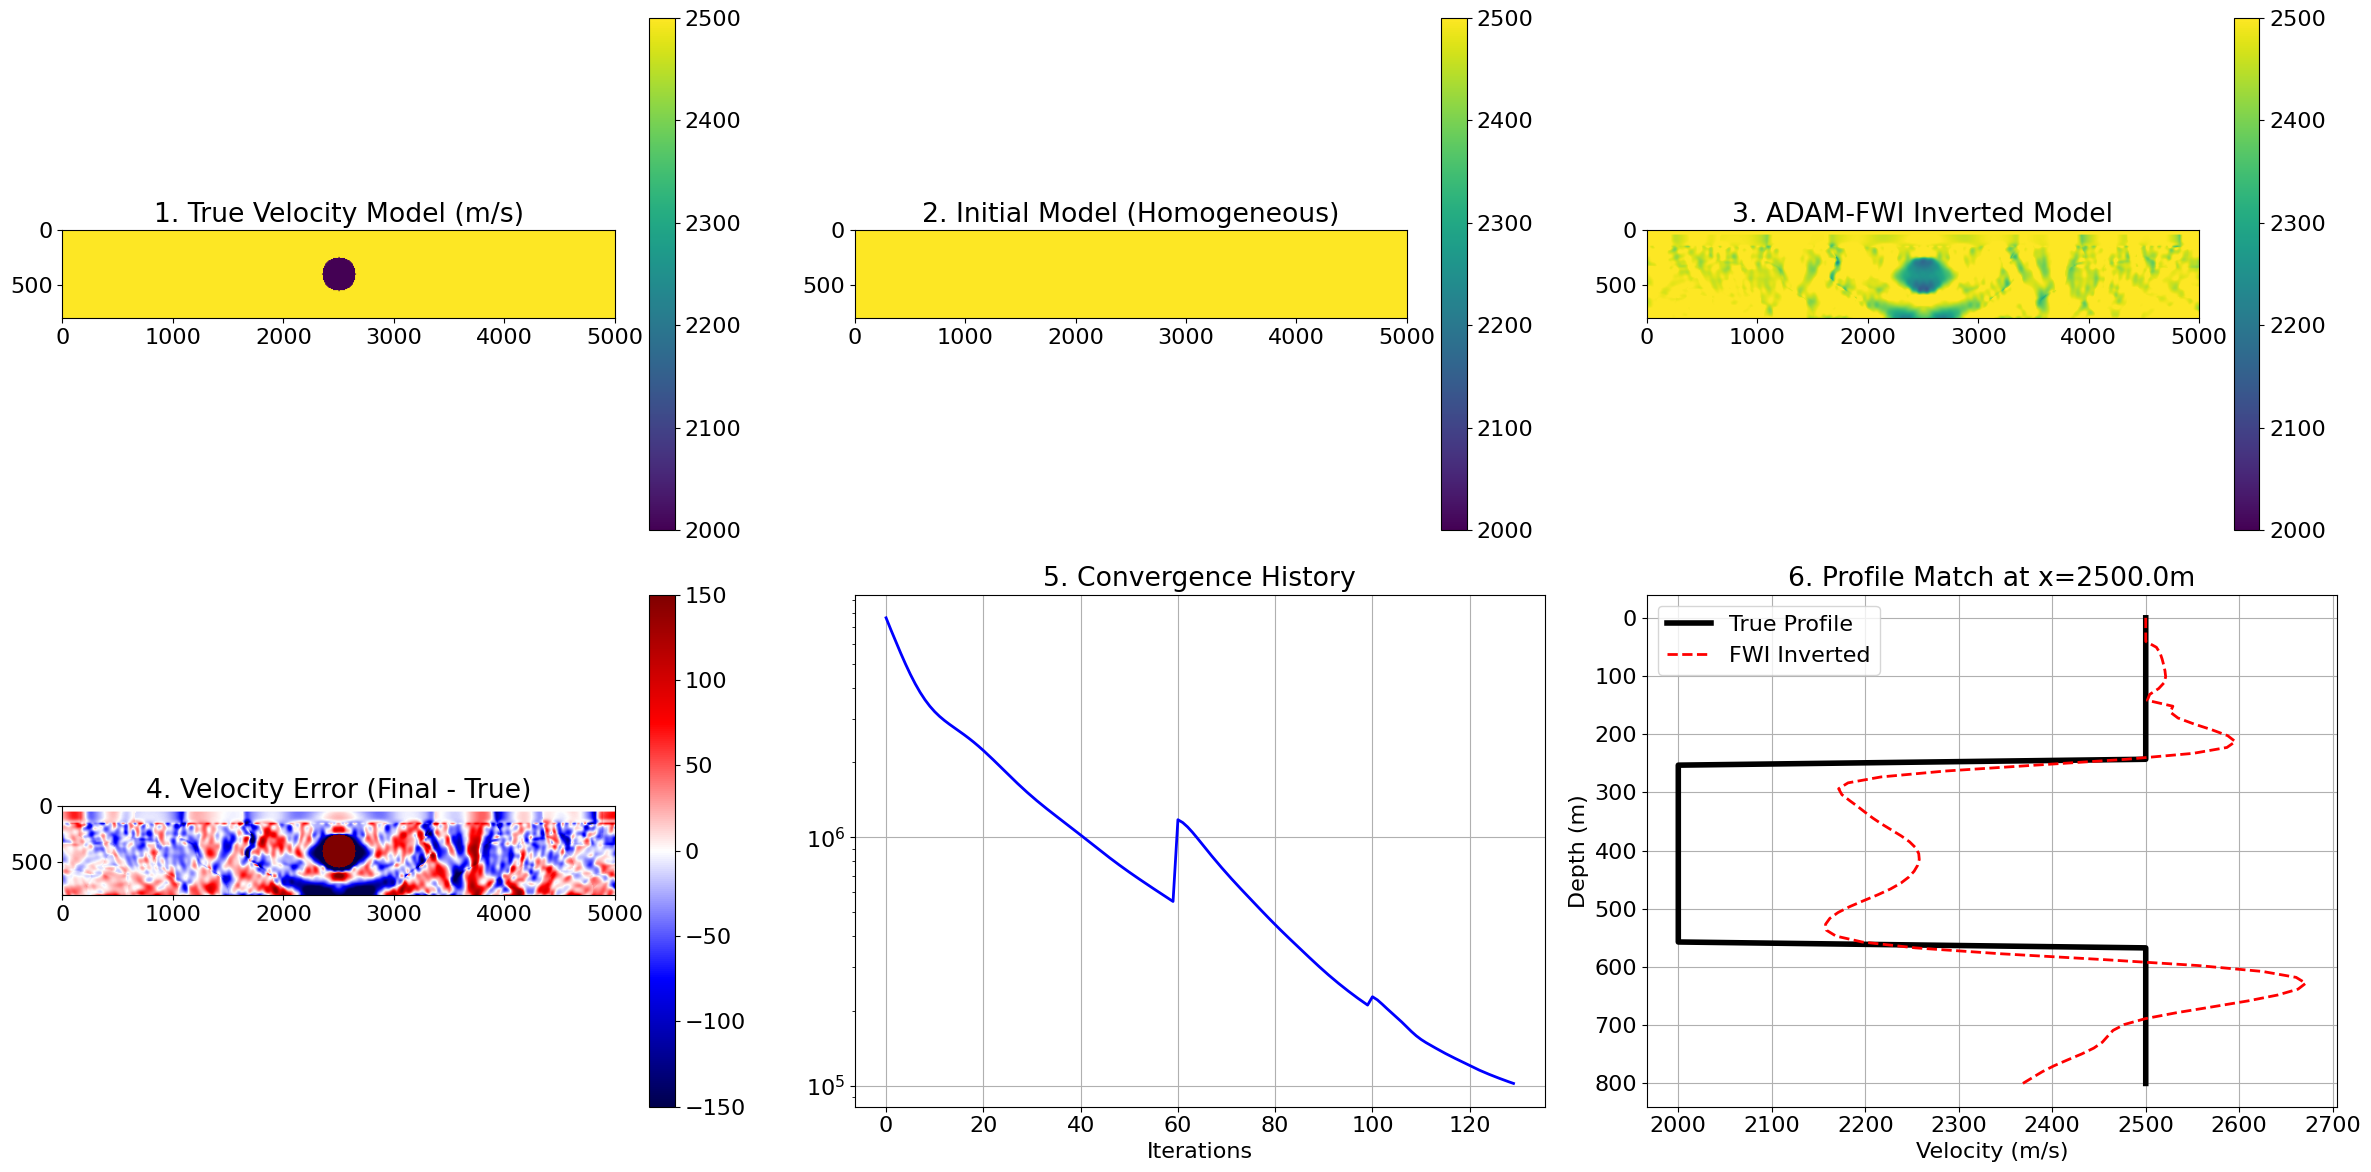

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# Devito configuration
os.environ['DEVITO_ARCH'] = 'gcc'
from devito import configuration, Function, Eq, Operator, norm, Min, Max
from examples.seismic import Model, AcquisitionGeometry, Receiver
from examples.seismic.acoustic import AcousticWaveSolver

# Qiskit imports
from qiskit.circuit.library import zz_feature_map, real_amplitudes
from qiskit_machine_learning.neural_networks import EstimatorQNN

configuration['log-level'] = 'WARNING'

# ------------------ 1. Setup: Grid & Models --------------------
nx, nz = 500, 80
shape = (nx, nz)
spacing = (10., 10.)
origin = (0., 0.)
nbl = 20

v0, v_anomaly = 2.5, 2.0  # km/s (Background vs Anomaly)

# Create True Model
velocity_true = np.full(shape, v0, dtype=np.float32)
cx, cz = nx // 2, nz // 2
radius = 15  # 150m radius
for i in range(nx):
    for j in range(nz):
        if (i - cx)**2 + (j - cz)**2 <= radius**2:
            velocity_true[i, j] = v_anomaly

model_true = Model(vp=velocity_true, origin=origin, shape=shape, spacing=spacing,
                   nbl=nbl, space_order=4, bcs="damp")

# Create Homogeneous Initial Model
velocity_init = np.full(shape, v0, dtype=np.float32)
model0 = Model(vp=velocity_init, origin=origin, shape=shape, spacing=spacing,
               nbl=nbl, space_order=4, bcs="damp")

# ------------------ 2. Quantum Optimizer Setup -----------------
num_qubits = 2
fmap = zz_feature_map(num_qubits)
ansatz = real_amplitudes(num_qubits, reps=1)
qc = fmap.compose(ansatz)
qnn = EstimatorQNN(circuit=qc, input_params=fmap.parameters, weight_params=ansatz.parameters)
q_weights = np.random.rand(qnn.num_weights)

def get_quantum_modifier(grad_data, weights):
    # Extract feature from gradient: Mean absolute value normalized
    feature = np.mean(np.abs(grad_data)) / (np.std(grad_data) + 1e-9)
    inputs = np.array([feature] * num_qubits)
    q_out = qnn.forward(inputs, weights)
    # Returns modifier in range ~[0.9, 1.1]
    return 1.0 + 0.1 * np.mean(q_out)

# ------------------ 3. Acquisition Geometry -------------------
nshots, nreceivers = 35, 250
t0, tn = 0.0, 1500.0
src_coords = np.empty((nshots, 2))
src_coords[:, 0] = np.linspace(0, model_true.domain_size[0], num=nshots)
src_coords[:, 1] = 20.
rec_coords = np.empty((nreceivers, 2))
rec_coords[:, 0] = np.linspace(0, model_true.domain_size[0], num=nreceivers)
rec_coords[:, 1] = 20.

# ------------------ 4. ADAM Initialization --------------------
padded_shape = model0.vp.data.shape
m = np.zeros(padded_shape, dtype=np.float32) # Momentum
v = np.zeros(padded_shape, dtype=np.float32) # RMS Prop
beta1, beta2 = 0.9, 0.999
epsilon = 1e-8
adam_t = 0

# ------------------ 5. Multiscale FWI Loop --------------------
# Starting at 3Hz is vital to recover the box-like velocity jump
frequencies = [0.003, 0.007, 0.012]
iterations = [60, 40, 30]
sigmas = [2.5, 1.5, 0.5] # Smoothing schedule
history = []
vp_curr = model0.vp
slice_core = (slice(nbl, -nbl), slice(nbl, -nbl))

# Masking to remove surface artifacts (mute top 150m)
mask = np.ones(shape, dtype=np.float32)
mask[:, :15] = 0.0
full_mask = np.pad(mask, ((nbl, nbl), (nbl, nbl)), mode='constant', constant_values=0)

print("--- Starting Hybrid ADAM FWI ---")
for f_idx, f0 in enumerate(frequencies):
    print(f"\n>> Stage {f_idx+1}: frequency {f0*1000} Hz")
    geometry = AcquisitionGeometry(model_true, rec_coords, src_coords, t0=t0, tn=tn, f0=f0, src_type='Ricker')
    solver = AcousticWaveSolver(model_true, geometry, space_order=4)
    base_lr = 0.005 # Learning rate for ADAM

    for it in range(iterations[f_idx]):
        adam_t += 1
        grad = Function(name="grad", grid=vp_curr.grid)
        d_obs = Receiver(name='d_obs', grid=vp_curr.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)
        d_syn = Receiver(name='d_syn', grid=vp_curr.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)
        res_rec = Receiver(name='res_rec', grid=vp_curr.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)

        # 1. Physics Step
        obj = 0.
        for i in range(nshots):
            geometry.src_positions[0, :] = src_coords[i, :]
            solver.forward(vp=model_true.vp, rec=d_obs)
            _, u0, _ = solver.forward(vp=vp_curr, save=True, rec=d_syn)
            res_rec.data[:] = d_syn.data[:] - d_obs.data[:]
            obj += .5 * norm(res_rec)**2
            # FIX: changed res=res_rec to rec=res_rec
            solver.gradient(rec=res_rec, u=u0, vp=vp_curr, grad=grad)

        history.append(obj)

        # 2. Gradient Processing (Muting + Smoothing)
        g_data = grad.data[:] * full_mask
        g_data = gaussian_filter(g_data, sigma=sigmas[f_idx])

        # 3. ADAM Update Calculations
        m = beta1 * m + (1 - beta1) * g_data
        v = beta2 * v + (1 - beta2) * (g_data**2)
        m_hat = m / (1 - beta1**adam_t)
        v_hat = v / (1 - beta2**adam_t)

        # 4. Quantum Parameter Nudge
        q_mod = get_quantum_modifier(g_data[slice_core], q_weights)
        current_lr = base_lr * q_mod

        # 5. Apply Model Update
        update_step = current_lr * m_hat / (np.sqrt(v_hat) + epsilon)
        vp_curr.data[:] = np.clip(vp_curr.data[:] + update_step, 1.4, 3.1)

        if it % 10 == 0:
            print(f"   Iteration {it:02d} | Objective: {obj:.3e} | Q-Modifier: {q_mod:.3f}")

# ------------------ 6. Visualization --------------------------
vp_final = vp_curr.data[slice_core] * 1000.0
vp_true_plot = model_true.vp.data[slice_core] * 1000.0
error = vp_final - vp_true_plot
depth = np.linspace(0, nz * spacing[1], nz)
extent = [0, nx*spacing[0], nz*spacing[1], 0]

fig, ax = plt.subplots(2, 3, figsize=(24, 12))

# Row 1: The Three Comparison Models
im1 = ax[0,0].imshow(vp_true_plot.T, cmap='viridis', extent=extent, vmin=2000, vmax=2500)
ax[0,0].set_title("1. True Velocity Model (m/s)")
plt.colorbar(im1, ax=ax[0,0])

im2 = ax[0,1].imshow(np.full_like(vp_final, v0*1000).T, cmap='viridis', extent=extent, vmin=2000, vmax=2500)
ax[0,1].set_title("2. Initial Model (Homogeneous)")
plt.colorbar(im2, ax=ax[0,1])

im3 = ax[0,2].imshow(vp_final.T, cmap='viridis', extent=extent, vmin=2000, vmax=2500)
ax[0,2].set_title("3. ADAM-FWI Inverted Model")
plt.colorbar(im3, ax=ax[0,2])

# Row 2: Diagnostics
im_e = ax[1,0].imshow(error.T, cmap='seismic', extent=extent, vmin=-150, vmax=150)
ax[1,0].set_title("4. Velocity Error (Final - True)")
plt.colorbar(im_e, ax=ax[1,0])

ax[1,1].plot(history, color='blue', linewidth=2)
ax[1,1].set_yscale('log')
ax[1,1].set_title("5. Convergence History")
ax[1,1].set_xlabel("Iterations")
ax[1,1].grid(True)

# Central Velocity Profile Matching
mid_x = nx // 2
ax[1,2].plot(vp_true_plot[mid_x, :], depth, 'k-', linewidth=4, label='True Profile')
ax[1,2].plot(vp_final[mid_x, :], depth, 'r--', linewidth=2, label='FWI Inverted')
ax[1,2].invert_yaxis()
ax[1,2].set_title(f"6. Profile Match at x={mid_x*spacing[0]}m")
ax[1,2].set_xlabel("Velocity (m/s)")
ax[1,2].set_ylabel("Depth (m)")
ax[1,2].legend()
ax[1,2].grid(True)

plt.tight_layout()
plt.show()